In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

In [2]:
movie_rating_df = pd.read_parquet("../data/processed/movie_rating_df.parquet")

In [3]:
print(movie_rating_df.shape)
movie_rating_df.head(3)

(25000095, 5)


,userid,movieid,rating,title,genres
0,1,296,5.0,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller
1,1,306,3.5,Three Colors: Red (Trois couleurs: Rouge) (1994),Drama
2,1,307,5.0,Three Colors: Blue (Trois couleurs: Bleu) (1993),Drama


In [4]:
unique_movie_rating = movie_rating_df.groupby("movieid").agg(
    title = ("title", "max"),
    avg_rating = ("rating", "mean"),
    no_ratings = ("rating", "count")
).reset_index()

print(unique_movie_rating.shape)
print()
unique_movie_rating.head(3)

(59047, 4)



,movieid,title,avg_rating,no_ratings
0,1,Toy Story (1995),3.893708,57309
1,2,Jumanji (1995),3.251527,24228
2,3,Grumpier Old Men (1995),3.142028,11804


In [ ]:
# Perform test train split at each userid level
test_ratio = 0.2
np.random.seed(42)

movie_rating_df['rand'] = np.random.rand(len(movie_rating_df))
movie_rating_df_sorted = movie_rating_df.sort_values(by=['userid', 'rand'])

movie_rating_df_sorted['rank_within_group'] = movie_rating_df_sorted.groupby('userid').cumcount() + 1
movie_rating_df_sorted['group_size'] = movie_rating_df_sorted.groupby('userid')['userid'].transform('count')

# For group_size > 1, calculate ceil(group_size * test_ratio). For group_size = 1, test_count should be 0.
movie_rating_df_sorted['calc_test_count'] = np.ceil(movie_rating_df_sorted['group_size'] * test_ratio).astype(int)
movie_rating_df_sorted['test_count_per_group'] = np.where(
    movie_rating_df_sorted['group_size'] > 1,
    movie_rating_df_sorted['calc_test_count'],
    0
)

is_in_test = (movie_rating_df_sorted['rank_within_group'] <= movie_rating_df_sorted['test_count_per_group'])

test_user_movie_df = movie_rating_df_sorted[is_in_test].drop(columns=['rand', 'rank_within_group', 'group_size', 'calc_test_count', 'test_count_per_group'])
train_user_movie_df = movie_rating_df_sorted[~is_in_test].drop(columns=['rand', 'rank_within_group', 'group_size', 'calc_test_count', 'test_count_per_group'])

print(f"Shape of training data: {train_user_movie_df.shape}")
print(f"Shape of testing data: {test_user_movie_df.shape}")
print(f"Ratio of Observations, Test to Input Df: {round(test_user_movie_df.shape[0] / (train_user_movie_df.shape[0] + test_user_movie_df.shape[0]), 2)}")

Shape of training data: (19936012, 5)
Shape of testing data: (5064083, 5)
Ratio of Observations, Test to Input Df: 0.2


In [6]:
# Display the first few rows of the training set
print("Train DataFrame:")
display(train_user_movie_df.head())

# Display the first few rows of the testing set
print("\nTest DataFrame:")
display(test_user_movie_df.head())

Train DataFrame:


,userid,movieid,rating,title,genres
31,1,5269,0.5,"Piano Teacher, The (La pianiste) (2001)",Drama
14,1,2068,2.5,Fanny and Alexander (Fanny och Alexander) (1982),Drama|Fantasy|Mystery
15,1,2161,3.5,"NeverEnding Story, The (1984)",Adventure|Children|Fantasy
49,1,7365,4.0,Noi the Albino (Nói albinói) (2003),Drama
57,1,8327,5.0,Dolls (2002),Drama|Romance



Test DataFrame:


,userid,movieid,rating,title,genres
10,1,1260,3.5,M (1931),Crime|Film-Noir|Thriller
42,1,6954,3.5,"Barbarian Invasions, The (Les invasions barbar...",Comedy|Crime|Drama|Mystery|Romance
58,1,8360,4.0,Shrek 2 (2004),Adventure|Animation|Children|Comedy|Musical|Ro...
29,1,4973,4.5,"Amelie (Fabuleux destin d'Amélie Poulain, Le) ...",Comedy|Romance
6,1,1175,3.5,Delicatessen (1991),Comedy|Drama|Romance


In [7]:
print(train_user_movie_df["userid"].nunique(), ",", test_user_movie_df["userid"].nunique())
print("This means all the users are in test and training set !")

162541 , 162541
This means all the users are in test and training set !


In [8]:
#test dataset is not required now.
file_path = Path("../data/processed/test_user_movie_df.parquet")

if file_path.exists():
    print("File already exists — not overwriting.")
else:
    test_user_movie_df.to_parquet(file_path, index=False, compression="snappy")
    print("File saved.")

File already exists — not overwriting.


In [9]:
train_uniq_movie_df = train_user_movie_df.groupby("movieid").agg(
    title = ("title", "max"),
    avg_rating = ("rating", "mean"),
    no_ratings = ("rating", "count")
).reset_index()

print(train_uniq_movie_df.shape)
print()
train_uniq_movie_df.head()

(56649, 4)



,movieid,title,avg_rating,no_ratings
0,1,Toy Story (1995),3.892475,45473
1,2,Jumanji (1995),3.251781,19231
2,3,Grumpier Old Men (1995),3.147792,9422
3,4,Waiting to Exhale (1995),2.872208,2015
4,5,Father of the Bride Part II (1995),3.054067,9331


In [10]:
print("Distribution of Movie Ratings in Training Dataset\n")

print(train_uniq_movie_df["no_ratings"].describe(
    percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
))

Distribution of Movie Ratings in Training Dataset

count    56649.000000
mean       351.921693
std       2013.373644
min          1.000000
50%          5.000000
75%         33.000000
90%        357.000000
95%       1275.600000
99%       8192.080000
max      64819.000000
Name: no_ratings, dtype: float64


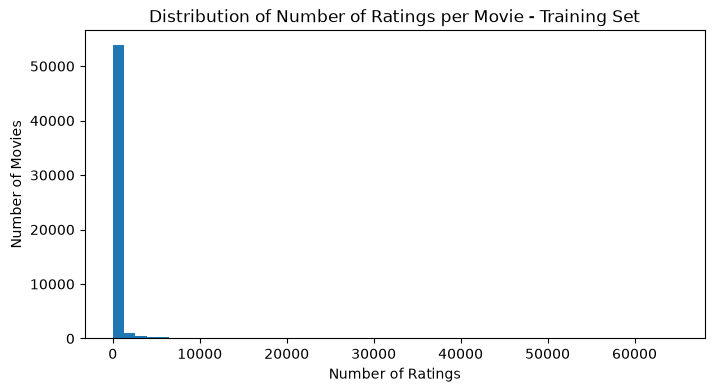

In [11]:
plt.figure(figsize=(8,4))
plt.hist(train_uniq_movie_df["no_ratings"], bins=50)
plt.xlabel("Number of Ratings")
plt.ylabel("Number of Movies")
plt.title("Distribution of Number of Ratings per Movie - Training Set")
plt.show()

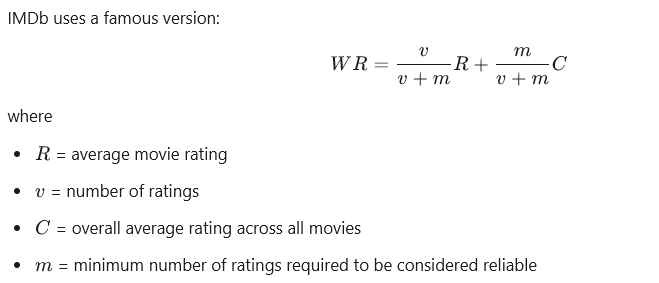

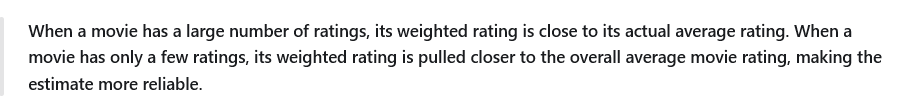

In [12]:
train_uniq_movie_df.head()

,movieid,title,avg_rating,no_ratings
0,1,Toy Story (1995),3.892475,45473
1,2,Jumanji (1995),3.251781,19231
2,3,Grumpier Old Men (1995),3.147792,9422
3,4,Waiting to Exhale (1995),2.872208,2015
4,5,Father of the Bride Part II (1995),3.054067,9331


In [13]:
min_no_ratings_reliable = 1500 #95% percentile rounded off to multiple of 100
ovr_mean_rating = train_uniq_movie_df["avg_rating"].mean()
print("Min no of ratings for reliability: ", min_no_ratings_reliable)
print("Overall mean rating across all movies: ", ovr_mean_rating)

train_uniq_movie_df["weighted_rating"] = (
    (train_uniq_movie_df["no_ratings"] / (train_uniq_movie_df["no_ratings"] + min_no_ratings_reliable)) * train_uniq_movie_df["avg_rating"]
    + (min_no_ratings_reliable / (train_uniq_movie_df["no_ratings"] + min_no_ratings_reliable)) * ovr_mean_rating
)

Min no of ratings for reliability:  1500
Overall mean rating across all movies:  3.0753846144461994


In [14]:
display(train_uniq_movie_df.loc[train_uniq_movie_df["no_ratings"] <= 10].head(3))
print()
display(train_uniq_movie_df.loc[train_uniq_movie_df["no_ratings"] >= 20000].head(3))

,movieid,title,avg_rating,no_ratings,weighted_rating
141,143,Gospa (1995),2.050000,10,3.068594
394,399,Girl in the Cadillac (1995),2.277778,9,3.070628
398,403,Two Crimes (Dos crímenes) (1995),2.150000,10,3.069256


,movieid,title,avg_rating,no_ratings,weighted_rating
0,1,Toy Story (1995),3.892475,45473,3.866382
9,10,GoldenEye (1995),3.419545,22466,3.398005
31,32,Twelve Monkeys (a.k.a. 12 Monkeys) (1995),3.908014,37424,3.875927


In [15]:
train_uniq_movie_df_pre_sorted = train_uniq_movie_df.sort_values(
  by='weighted_rating',
  ascending=False
)

watched_movies_by_user = (
    train_user_movie_df
    .groupby('userid')['movieid']
    .apply(set).
    to_dict()
)

In [16]:
new_user_top_n_recommendations = train_uniq_movie_df_pre_sorted.head(10)
new_user_top_n_recommendations

,movieid,title,avg_rating,no_ratings,weighted_rating
314,318,"Shawshank Redemption, The (1994)",4.414518,64429,4.384051
840,858,"Godfather, The (1972)",4.325074,41729,4.281711
49,50,"Usual Suspects, The (1995)",4.286023,43909,4.246032
522,527,Schindler's List (1993),4.245748,47974,4.210264
1190,1221,"Godfather: Part II, The (1974)",4.259556,27183,4.197628
2867,2959,Fight Club (1999),4.228549,46793,4.192731
1164,1193,One Flew Over the Cuckoo's Nest (1975),4.220227,28734,4.163428
292,296,Pulp Fiction (1994),4.187800,63256,4.162033
734,750,Dr. Strangelove or: How I Learned to Stop Worr...,4.221426,21208,4.145723
883,904,Rear Window (1954),4.239993,16088,4.140668


In [17]:
file_path = Path("../data/processed/new_user_top_n_recommendations.parquet")

if file_path.exists():
    print("File already exists — not overwriting.")
else:
    new_user_top_n_recommendations.to_parquet(file_path, index=False, compression="snappy")
    print("File saved.")

File already exists — not overwriting.


In [18]:
#selection of top_n movies per user which are not in their training set i.e. recommend only the movie they haven't watched yet !
popular_movies = train_uniq_movie_df_pre_sorted.to_dict("records")

recommendations = []

for user_id, watched_movies in watched_movies_by_user.items():

    top_movies = []

    for movie in popular_movies:

        if movie["movieid"] in watched_movies:
            continue

        top_movies.append({
            "userid": user_id,
            "movieid": movie["movieid"],
            "title": movie["title"],
            "weighted_rating": movie["weighted_rating"]
        })

        if len(top_movies) == 10:
            break

    recommendations.extend(top_movies)

existing_user_top_n_recommendations = pd.DataFrame(recommendations)

In [19]:
existing_user_top_n_recommendations.loc[existing_user_top_n_recommendations["userid"] == 2].reset_index(drop=True)

,userid,movieid,title,weighted_rating
0,2,318,"Shawshank Redemption, The (1994)",4.384051
1,2,50,"Usual Suspects, The (1995)",4.246032
2,2,1221,"Godfather: Part II, The (1974)",4.197628
3,2,2959,Fight Club (1999),4.192731
4,2,1193,One Flew Over the Cuckoo's Nest (1975),4.163428
5,2,296,Pulp Fiction (1994),4.162033
6,2,750,Dr. Strangelove or: How I Learned to Stop Worr...,4.145723
7,2,904,Rear Window (1954),4.140668
8,2,912,Casablanca (1942),4.137709
9,2,5618,Spirited Away (Sen to Chihiro no kamikakushi) ...,4.123821


In [20]:
existing_user_top_n_recommendations.loc[existing_user_top_n_recommendations["userid"] == 3].reset_index(drop=True)

,userid,movieid,title,weighted_rating
0,3,1221,"Godfather: Part II, The (1974)",4.197628
1,3,1193,One Flew Over the Cuckoo's Nest (1975),4.163428
2,3,750,Dr. Strangelove or: How I Learned to Stop Worr...,4.145723
3,3,904,Rear Window (1954),4.140668
4,3,2571,"Matrix, The (1999)",4.127722
5,3,5618,Spirited Away (Sen to Chihiro no kamikakushi) ...,4.123821
6,3,1203,12 Angry Men (1957),4.121308
7,3,1213,Goodfellas (1990),4.120089
8,3,2019,Seven Samurai (Shichinin no samurai) (1954),4.105138
9,3,1136,Monty Python and the Holy Grail (1975),4.094449


In [21]:
file_path = Path("../data/processed/existing_user_top_n_recommendations.parquet")

if file_path.exists():
    print("File already exists — not overwriting.")
else:
    existing_user_top_n_recommendations.to_parquet(file_path, index=False, compression="snappy")
    print("File saved.")

File already exists — not overwriting.


In [22]:
print(movie_rating_df['userid'].nunique(), ",", existing_user_top_n_recommendations.shape[0])
print("For each user, we need 10 unwatched movies. Hence this is the expected number of recommendations.")

162541 , 1625410
For each user, we need 10 unwatched movies. Hence this is the expected number of recommendations.
